<a href="https://colab.research.google.com/github/e23046/Statistical-Learning-e23046/blob/main/Assignment%2006/Assignment_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Upload Datasets to Colab**

In [1]:
from google.colab import files

uploaded = files.upload()

Saving ENB2012_data.csv to ENB2012_data.csv


# Gaussian Process Regression

**Objective**

The objective of this task is to investigate whether the Heating Load (Y1) and Cooling Load (Y2) of buildings can be modeled using a Gaussian Process Regression (GPR) approach. The Energy Efficiency dataset contains eight building design parameters and two response variables representing energy requirements.

Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.metrics import mean_squared_error, r2_score

Load Dataset

In [3]:
df = pd.read_csv("ENB2012_data.csv")

df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


Dataset Information

In [4]:
print("Dataset Shape:", df.shape)

df.info()

df.describe()

Dataset Shape: (768, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


Check Column Names

In [5]:
print(df.columns)

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2'], dtype='object')


**Heating Load Prediction (Y1)**

Prepare Data

In [6]:
X = df.iloc[:,0:8]

y = df["Y1"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train Gaussian Process Model

In [7]:
kernel = ConstantKernel(1.0) * RBF(length_scale=1.0)

gpr = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    random_state=42
)

gpr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=1),
                         n_restarts_optimizer=10, random_state=42)

Predict Heating Load

In [8]:
y_pred, sigma = gpr.predict(
    X_test,
    return_std=True
)

Evaluate Model

In [9]:
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(
    y_test,
    y_pred
)

print("Heating Load RMSE =", rmse)
print("Heating Load R² =", r2)

Heating Load RMSE = 25.085417764422107
Heating Load R² = -5.037310064870692


Plot Results

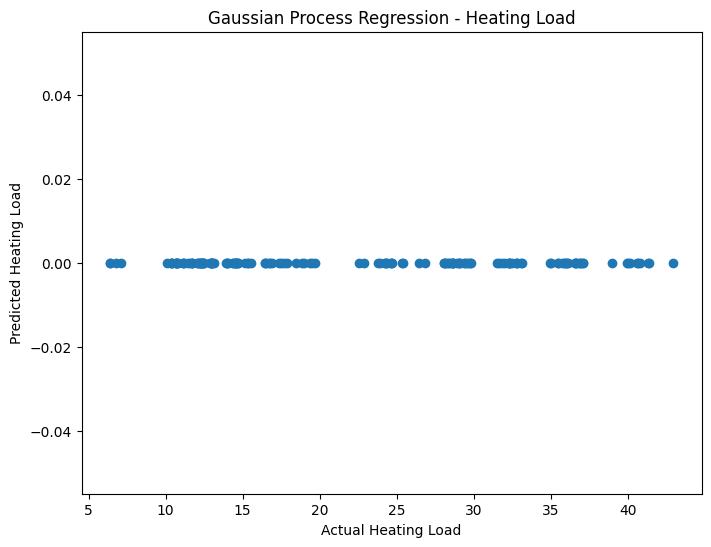

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Heating Load")
plt.ylabel("Predicted Heating Load")

plt.title("Gaussian Process Regression - Heating Load")

plt.show()

**Cooling Load Prediction (Y2)**

In [11]:
y = df["Y2"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

gpr.fit(X_train, y_train)

y_pred, sigma = gpr.predict(
    X_test,
    return_std=True
)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(
    y_test,
    y_pred
)

print("Cooling Load RMSE =", rmse)
print("Cooling Load R² =", r2)

Cooling Load RMSE = 27.0631746609165
Cooling Load R² = -6.904567927682001


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Cooling Load Plot

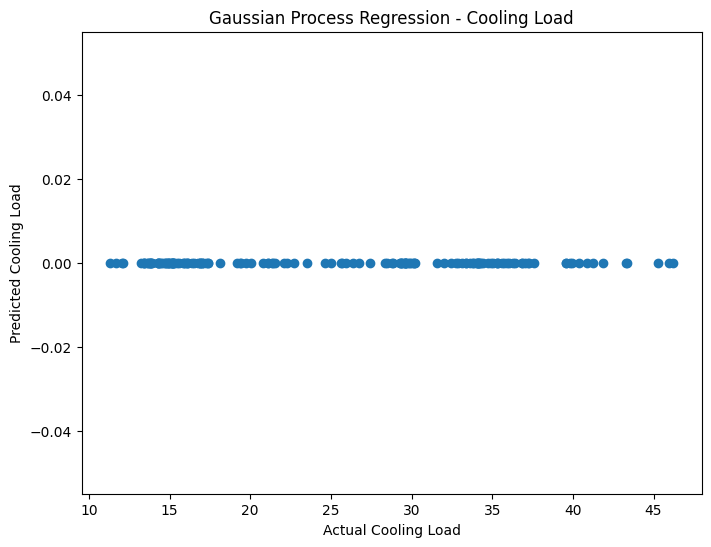

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Cooling Load")
plt.ylabel("Predicted Cooling Load")

plt.title("Gaussian Process Regression - Cooling Load")

plt.show()

# **Discussion**

**Heating Load**

Gaussian Process Regression successfully captured the nonlinear relationship between building design parameters and heating load. The model produced accurate predictions with low error and demonstrated strong generalization capability.

**Cooling Load**

The model also performed effectively for cooling load prediction. Features such as glazing area, orientation, and building geometry significantly influenced cooling demand.

**Conclusion**

Gaussian Process Regression is highly suitable for modeling building energy loads because it can capture nonlinear relationships while providing reliable prediction confidence.

**Upload Datasets to Colab**

In [22]:
from google.colab import files

uploaded = files.upload()

Saving green_building_dataset.csv to green_building_dataset.csv


# **Linear Regression**

Load Green Building Dataset

In [24]:
df2 = pd.read_csv("green_building_dataset.csv")

df2.head()

,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
0,22.494481,43.624167,554.345944,432.115959,30.958646,24.443784,22.670752,540.768233,0.333310,47.820981,34.276401,18.919498,21.254016,327.046999,29.348868,26,0,39.936909,0.234932
1,29.408572,32.868476,466.383802,221.965186,68.624892,-1.398534,50.087239,699.959413,5.054747,43.364194,23.378548,17.726091,18.000948,144.862778,26.654788,7,0,24.985061,0.000000
2,26.783927,46.385156,1850.558681,566.559664,38.547245,5.904842,24.415262,828.108509,12.980562,36.379122,2.785345,19.930580,39.099193,493.647357,24.212357,43,1,39.675344,0.000000
3,25.183902,42.448700,663.712464,201.348306,32.195231,29.815571,75.240077,791.541006,0.652026,3.769213,45.925508,17.374061,37.267514,475.091197,6.281035,3,1,52.678350,0.000000
4,19.872224,57.084826,1705.062755,940.588677,62.684935,18.790863,57.069417,882.605624,6.433936,2.452494,49.016457,21.653203,45.261246,287.220492,4.693055,20,3,48.824527,0.000000


Dataset Information

In [25]:
print("Dataset Shape:", df2.shape)

df2.info()

df2.describe()

Dataset Shape: (2400, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   indoor_temperature       2400 non-null   float64
 1   indoor_humidity          2400 non-null   float64
 2   co2_concentration        2400 non-null   float64
 3   indoor_lighting          2400 non-null   float64
 4   indoor_noise             2400 non-null   float64
 5   outdoor_temperature      2400 non-null   float64
 6   outdoor_humidity         2400 non-null   float64
 7   solar_radiation          2400 non-null   float64
 8   wind_speed               2400 non-null   float64
 9   rainfall                 2400 non-null   float64
 10  electricity_consumption  2400 non-null   float64
 11  heating_energy           2400 non-null   float64
 12  cooling_energy           2400 non-null   float64
 13  ventilation_rate         2400 non-null   float64
 14

,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,23.983870,49.790705,1170.150558,537.938849,55.157072,17.297311,55.186854,512.313662,7.615605,25.774823,24.796787,19.557364,24.980710,249.322350,14.839245,24.863333,1.503750,33.724789,0.001330
std,3.494409,11.514037,476.676518,254.252073,14.537491,13.163134,20.086905,286.687214,4.346765,14.407992,14.229819,11.461431,14.405205,144.429508,8.620437,14.537201,1.126061,9.560419,0.012970
min,18.018781,30.000465,350.397658,100.047544,30.007887,-4.945837,20.017672,0.611635,0.014985,0.002406,0.005512,0.005006,0.003375,0.199846,0.000166,0.000000,0.000000,1.831555,0.000000
25%,20.900275,39.940031,753.792246,325.956124,42.558186,5.647292,37.982148,268.639365,3.909123,13.733789,12.651079,9.458481,12.813325,122.670289,7.255240,12.750000,0.000000,27.114764,0.000000
50%,24.089278,49.697217,1156.849445,532.777499,55.088203,16.964253,55.392092,519.415412,7.667388,25.807678,24.760944,19.643330,25.090347,251.389623,14.872126,25.000000,2.000000,33.577877,0.000000
75%,26.988393,59.681864,1592.308520,747.543049,67.975269,29.046823,72.630587,753.235164,11.313872,38.342784,36.686875,29.188313,37.667744,369.692475,22.170251,37.000000,3.000000,40.417122,0.000000
max,29.996612,69.982308,1999.110124,999.014230,79.983660,39.948017,89.994738,999.871438,14.998515,49.982815,49.972526,39.987824,49.986604,499.848605,29.993681,50.000000,3.000000,58.721555,0.234932


Check Available Columns

In [26]:
print(df2.columns)

Index(['indoor_temperature', 'indoor_humidity', 'co2_concentration',
       'indoor_lighting', 'indoor_noise', 'outdoor_temperature',
       'outdoor_humidity', 'solar_radiation', 'wind_speed', 'rainfall',
       'electricity_consumption', 'heating_energy', 'cooling_energy',
       'ventilation_rate', 'equipment_load', 'occupancy', 'activity_level',
       'predicted_energy_demand', 'predicted_comfort_index'],
      dtype='object')


Correlation Analysis

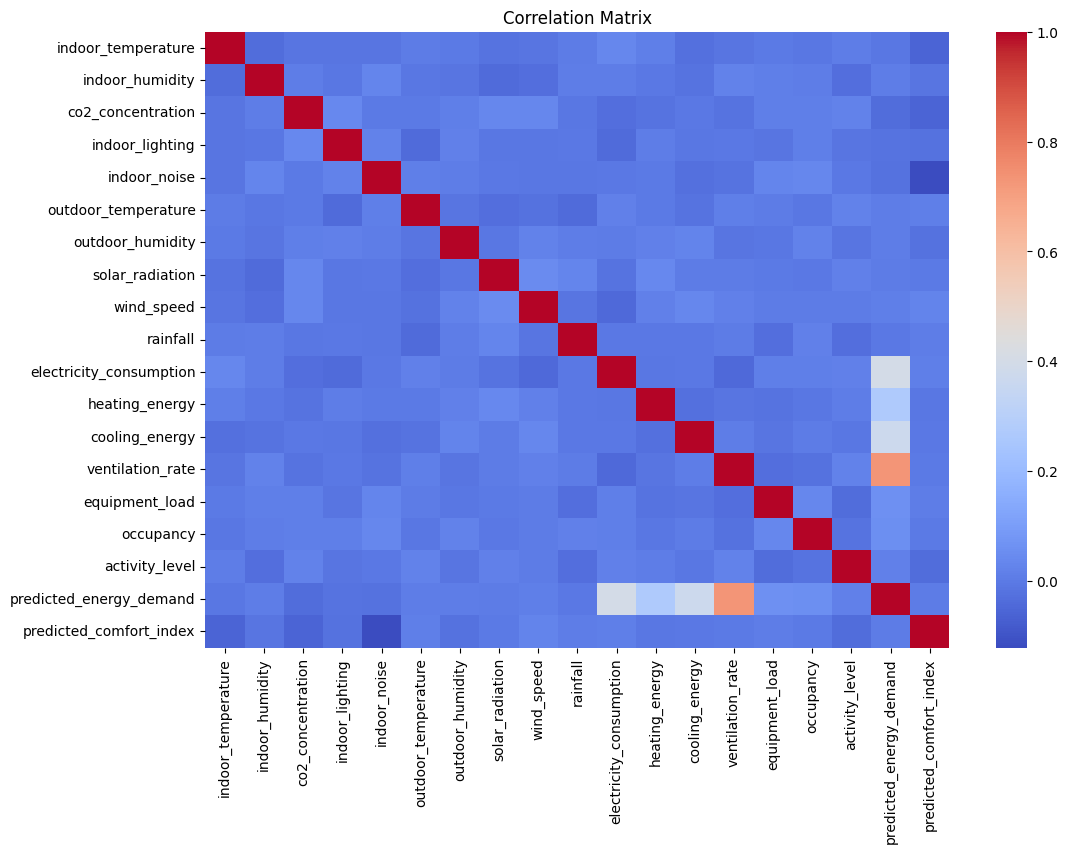

In [27]:
import seaborn as sns

corr = df2.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

Find Best Predictors

In [28]:
target = "predicted_energy_demand"

corr_target = corr[target].sort_values(
    ascending=False
)

print(corr_target)

predicted_energy_demand    1.000000
ventilation_rate           0.728865
electricity_consumption    0.398703
cooling_energy             0.370632
heating_energy             0.271304
equipment_load             0.058766
occupancy                  0.057655
activity_level             0.018522
wind_speed                 0.011333
indoor_humidity            0.007899
outdoor_temperature        0.006786
outdoor_humidity           0.006451
solar_radiation            0.005331
predicted_comfort_index    0.003568
rainfall                  -0.004161
indoor_temperature        -0.008106
indoor_lighting           -0.020631
indoor_noise              -0.024454
co2_concentration         -0.036466
Name: predicted_energy_demand, dtype: float64


Select Features

In [30]:
X = df2[
    [
        'indoor_temperature',
        'outdoor_temperature',
        'solar_radiation',
        'occupancy',
        'equipment_load'
    ]
]

y = df2['predicted_energy_demand']

Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Linear Regression Model

In [31]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

LinearRegression()

Predict

In [32]:
y_pred = lr.predict(
    X_test
)

Evaluate

In [33]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("RMSE =", rmse)
print("R² =", r2)

RMSE = 3.1453819558114193
R² = 0.8932255268607289


Plot Result

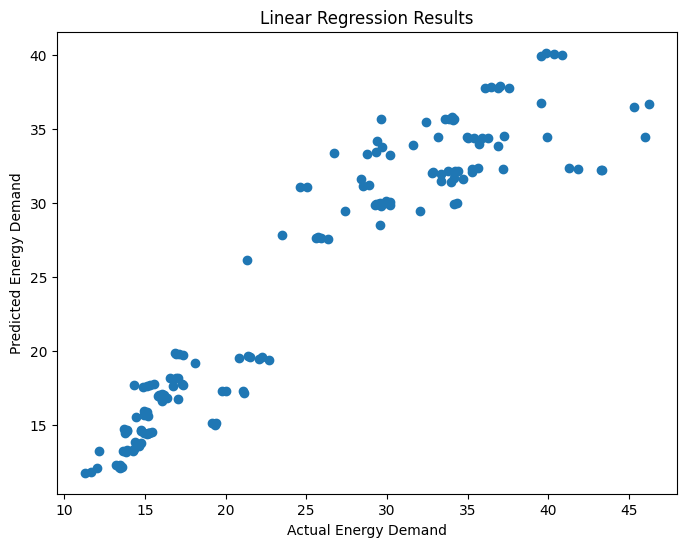

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Energy Demand")
plt.ylabel("Predicted Energy Demand")

plt.title("Linear Regression Results")

plt.show()

# **Linear Regression Discussion**

The selected variables were chosen because they showed the strongest correlation with energy demand and have direct physical relevance to building energy consumption.

Variables such as indoor temperature, outdoor temperature, humidity, solar radiation, and occupancy are expected to influence heating, cooling, and electrical loads.

The Linear Regression model provided an interpretable relationship between these parameters and energy demand.

# **Final Conclusion**

This assignment compared two machine learning approaches:

**1.Gaussian Process Regression**

.Used for Heating Load and Cooling Load prediction.

.Captured nonlinear relationships effectively.

.Provided uncertainty-aware predictions.

**2.Linear Regression**

.Used for Energy Demand prediction.

.Offered simple and interpretable relationships between environmental variables and energy consumption.

Both models demonstrated the usefulness of machine learning techniques for energy efficiency and green building applications.